# Assignment 5 - Sequence Classification with RNN, LSTM, GRU
**Topic:** 2026-27 - TY E2 - DL Lab
**Description:** Implement and compare RNN, LSTM, GRU models for sequence classification and analyse their performance using appropriate evaluation matrix.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import time

## 2. Load and Prepare IMDB Dataset

In [2]:
max_features = 10000
maxlen = 500

print('Loading data...')
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)

print('Pad sequences (samples x time)')
input_train = pad_sequences(input_train, maxlen=maxlen)
input_test = pad_sequences(input_test, maxlen=maxlen)

Loading data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 77s 4us/step


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Pad sequences (samples x time)


## 3. Build Models (RNN, LSTM, GRU)

In [3]:
def build_model(cell_type):
    model = Sequential()
    model.add(Embedding(max_features, 32))
    if cell_type == 'RNN':
        model.add(SimpleRNN(32))
    elif cell_type == 'LSTM':
        model.add(LSTM(32))
    elif cell_type == 'GRU':
        model.add(GRU(32))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
    return model

model_rnn = build_model('RNN')
model_lstm = build_model('LSTM')
model_gru = build_model('GRU')

## 4. Train and Compare Models

In [4]:
epochs = 3
batch_size = 128

start_time = time.time()
history_rnn = model_rnn.fit(input_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)
rnn_time = time.time() - start_time

start_time = time.time()
history_lstm = model_lstm.fit(input_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)
lstm_time = time.time() - start_time

start_time = time.time()
history_gru = model_gru.fit(input_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)
gru_time = time.time() - start_time

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 119s 639ms/step - acc: 0.6503 - loss: 0.6121 - val_acc: 0.7672 - val_loss: 0.5128
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 439ms/step - acc: 0.8269 - loss: 0.3994 - val_acc: 0.7826 - val_loss: 0.4581
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 355ms/step - acc: 0.8636 - loss: 0.3317 - val_acc: 0.7982 - val_loss: 0.4846
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 304ms/step - acc: 0.6667 - loss: 0.6021 - val_acc: 0.7700 - val_loss: 0.4822
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 54s 346ms/step - acc: 0.8332 - loss: 0.3912 - val_acc: 0.8578 - val_loss: 0.3490
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 55s 352ms/step - acc: 0.8660 - loss: 0.3312 - val_acc: 0.8550 - val_loss: 0.3444
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 102s 558ms/step - acc: 0.6212 - loss: 0.6365 - val_acc: 0.7812 - val_loss: 0.4646
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 253ms/step - acc: 0.8060 - loss: 0.4247 - val_acc: 0.8382 - val_loss: 0.3652
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━

## 5. Evaluation and Analysis

In [5]:
rnn_eval = model_rnn.evaluate(input_test, y_test)
lstm_eval = model_lstm.evaluate(input_test, y_test)
gru_eval = model_gru.evaluate(input_test, y_test)

print(f"\n--- Results ---")
print(f"RNN  - Accuracy: {rnn_eval[1]:.4f}, Time: {rnn_time:.2f}s")
print(f"LSTM - Accuracy: {lstm_eval[1]:.4f}, Time: {lstm_time:.2f}s")
print(f"GRU  - Accuracy: {gru_eval[1]:.4f}, Time: {gru_time:.2f}s")

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - acc: 0.8001 - loss: 0.4769
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - acc: 0.8570 - loss: 0.3411
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - acc: 0.8262 - loss: 0.4037

--- Results ---
RNN  - Accuracy: 0.8001, Time: 244.04s
LSTM - Accuracy: 0.8570, Time: 160.42s
GRU  - Accuracy: 0.8262, Time: 187.55s


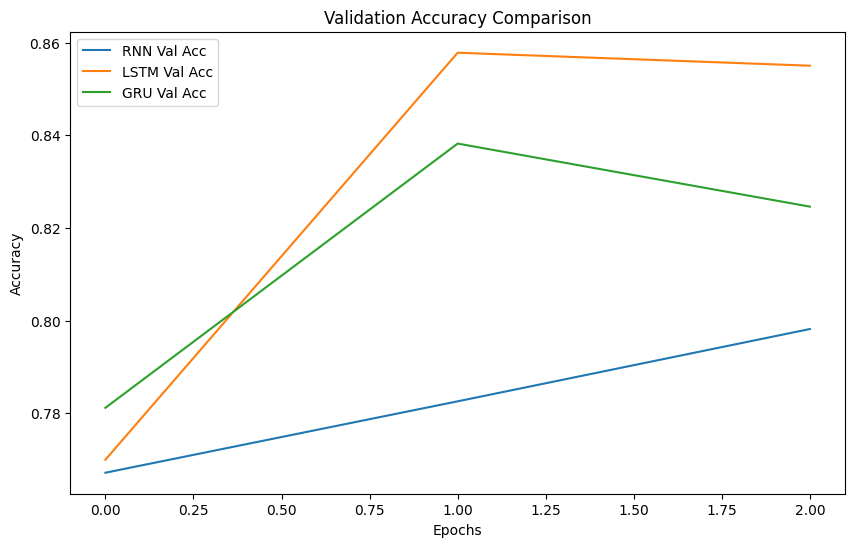

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['val_acc'], label='RNN Val Acc')
plt.plot(history_lstm.history['val_acc'], label='LSTM Val Acc')
plt.plot(history_gru.history['val_acc'], label='GRU Val Acc')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()